# Figure 6.

| Author  | Stanley A. Baronett  |
|---------|----------------------|
| Created |  03/04/2026          |
| Updated |  03/04/2026          |

Figure 2 replotted with faded lines and with dashed lines showing $n_\mathrm{p} = 9$.

In [1]:
#===============================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1 import AxesGrid
import numpy as np
import pandas as pd

res = 512
root = f'../{res}/src'
n_ps = ['np1', 'np9']
runs = {
    f'dust_particles': {
        'ls': 'dotted',
        'codes' : {
            'Athena':       'tab:green',
            'Athena++':     'tab:red',
            'Pencil':       'tab:blue',
            'PLUTO':        'tab:pink',
        }
    }
}

Athena samples
	  Total: 10001
	Strided: 667
	Per 10T: 1000
Athena++ samples
	  Total: 2000
	Strided: 667
	Per 10T: 222
Pencil samples
	  Total: 2925
	Strided: 732
	Per 10T: 292
PLUTO samples
	  Total: 1002
	Strided: 501
	Per 10T: 111
Athena++ samples
	  Total: 100014
	Strided: 633
	Per 10T: 10001
FARGO3D samples
	  Total: 631
	Strided: 631
	Per 10T: 63
Idefix samples
	  Total: 1002
	Strided: 501
	Per 10T: 100
LA-COMPASS samples
	  Total: 31401
	Strided: 641
	Per 10T: 3489
PLUTO samples
	  Total: 1001
	Strided: 501
	Per 10T: 100
Athena samples
	  Total: 10001
	Strided: 667
	Per 10T: 1000
Athena++ samples
	  Total: 2001
	Strided: 667
	Per 10T: 200
Pencil samples
	  Total: 3070
	Strided: 768
	Per 10T: 341
PLUTO samples
	  Total: 1002
	Strided: 501
	Per 10T: 111
Athena++ samples
	  Total: 100014
	Strided: 633
	Per 10T: 10001
FARGO3D samples
	  Total: 631
	Strided: 631
	Per 10T: 63
Idefix samples
	  Total: 1002
	Strided: 501
	Per 10T: 100
LA-COMPASS samples
	  Total: 31401
	Strided: 641
	P

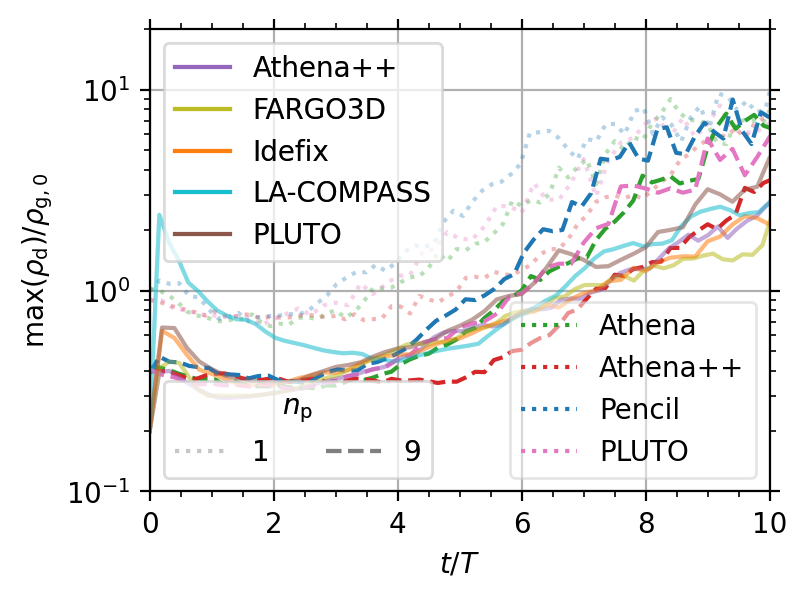

In [2]:
#===============================================================================
def print_samples(code, t, step, dt, window):
    """Print the number of samples in the time series."""
    print(f'{code} samples\n=======================')
    print(f'\t  Total: {len(t)}')
    print(f'\tStrided: {len(t[::step])}')
    print(f'\tPer {dt}T: {window}')

diag = True
dt = 10  # [T]

# Lowest cadence
path = f'{root}/dust_fluid/FARGO3D'
n_min = len(np.load(f'{path}/time_series.npz')['t'])

# Temporarily add fluid runs
fluid_runs = {
    'dust_fluid': {
        'ls': 'solid',
        'codes' : {
            'Athena++':     'tab:purple',
            'FARGO3D':      'tab:olive',
            'Idefix':       'tab:orange',
            'LA-COMPASS':   'tab:cyan',
            'PLUTO':        'tab:brown'
        }
    }
}
runs.update(fluid_runs)

# Plot
fig, ax = plt.subplots(figsize=(4, 3), dpi=200)
for n_p in n_ps:
    for key, value in runs.items():
        c_handles = []
        for code, color in value['codes'].items():
            if n_p == 'np1' or key == 'dust_fluid':
                alpha = 0.33
                ls = value['ls']
                path = f'{root}/{key}/{n_p}' if key != 'dust_fluid' else f'{root}/{key}'
                c_handles.append(ax.plot([],[], c=color, label=code, ls=ls)[0])
            else:
                alpha = 1.0
                ls = 'dashed'
                path = f'{root}/{key}/{n_p}' 
            path += f'/{code}'
            data = np.load(f'{path}/time_series.npz')
            t = data['t']
            # Strided
            step = len(t)//n_min
            if step < 2:
                step = 1 if len(t)%n_min/n_min < 0.5 else 2
            try:
                ax.plot(t[::step], data['maxrhod'][::step], alpha=alpha,
                        c=color, ls=ls)
            except KeyError:
                print(code)
            window = len(t)//int(t[-1]/dt)
            print_samples(code, t, step, dt, window) if diag else None
        if n_p == 'np1' or key == 'dust_fluid':
            loc = 'upper left' if key == 'dust_fluid' else 'lower right'
            ax.add_artist(ax.legend(framealpha=0.5, handles=c_handles, loc=loc))

# Remove fluid runs
runs.pop('dust_fluid')

# Custom legends
ls_handles = []
ls_handles.append(ax.plot([], [], alpha=0.33, c='tab:gray', ls='dotted',
                          label='1')[0])
ls_handles.append(ax.plot([], [], c='tab:gray', ls='dashed', label='9')[0])
ax.add_artist(ax.legend(framealpha=0.5, handles=ls_handles, loc='lower left',
                        ncol=2, title=r'$n_\mathrm{p}$'))

# Format plots
ax.grid()
ax.minorticks_on()
ax.set(xlabel=r'$t/T$', xlim=(0, 10), ylim=(1e-1, 2e1), yscale='log',
       ylabel=rf'$\max(\rho_\mathrm{{d}})/\rho_\mathrm{{g,0}}$')
ax.tick_params(axis='both', which='both', top=True, right=True)